# Part 3: Advanced Anomaly Detection

This section identifies statistical, behavioral, and correlated anomalies in network traffic to detect potential security threats.

Preparation

In [63]:
# Ensure proper datetime
df['startDateTime'] = pd.to_datetime(df['startDateTime'])

# Time windows (1 hour)
df['time_window'] = df['startDateTime'].dt.floor('1h')

(a) Statistical Traffic Analysis

Traffic Volume Anomalies (Z-score)

In [64]:
traffic = df.groupby('time_window').size()

z_scores = (traffic - traffic.mean()) / traffic.std()

anomalies = traffic[z_scores.abs() > 3]

print("Anomalous windows:", len(anomalies))
anomalies.head()

Anomalous windows: 2


,0
time_window,
2010-06-13 10:00:00,67952
2010-06-15 16:00:00,63821


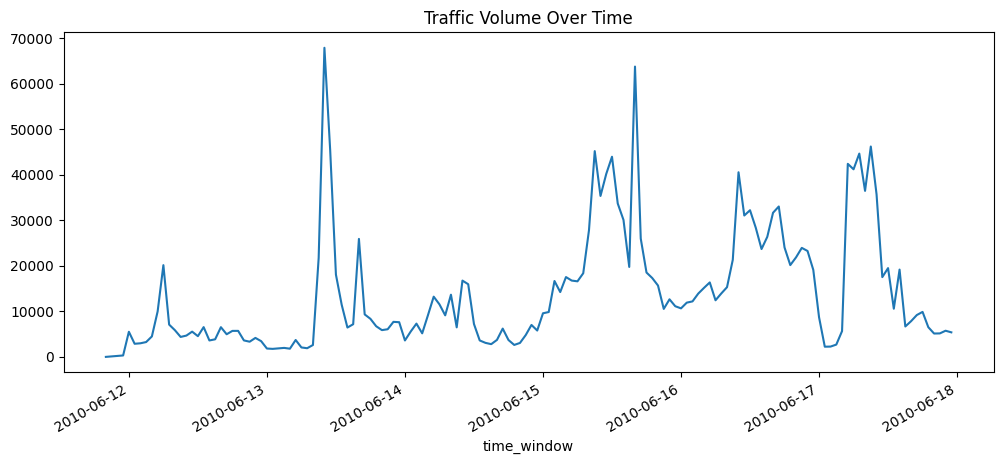

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
traffic.plot()
plt.title("Traffic Volume Over Time")
plt.show()

Z-score analysis is used to identify statistically rare traffic volumes using a ±3 standard deviation threshold.

Packet Size Anomalies

In [66]:
df['packet_size'] = (
    (df['totalSourceBytes'] + df['totalDestinationBytes']) /
    (df['totalSourcePackets'] + df['totalDestinationPackets'])
)

packet_z = (df['packet_size'] - df['packet_size'].mean()) / df['packet_size'].std()

packet_anomalies = df[packet_z.abs() > 3]

print("Packet anomalies:", len(packet_anomalies))

Packet anomalies: 48


Extreme packet sizes may indicate abnormal payloads, malformed packets, or unusual communication patterns.

Protocol Distribution Shift

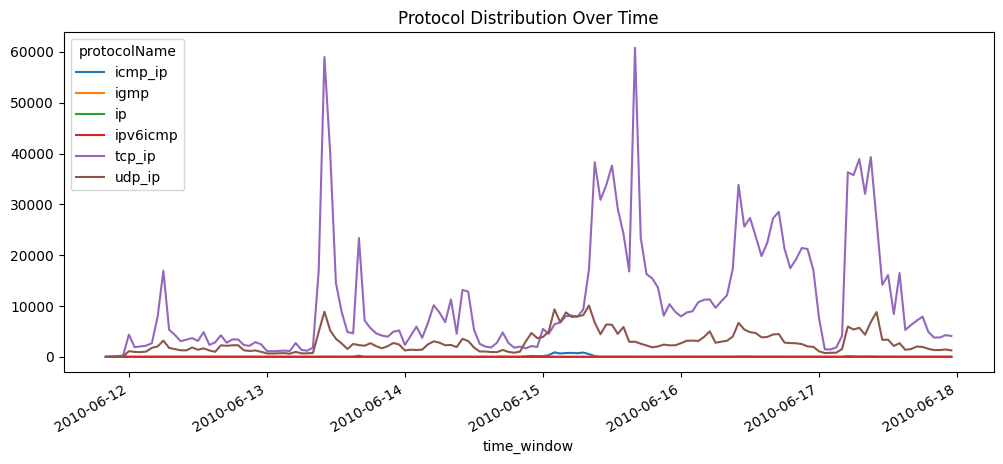

In [67]:
protocol_by_time = df.groupby(['time_window', 'protocolName']).size().unstack().fillna(0)

protocol_by_time.plot(figsize=(12,5))
plt.title("Protocol Distribution Over Time")
plt.show()

Sudden changes in protocol distribution may indicate scanning activity or protocol misuse.

(b) Behavioral Analysis

Sudden Activity Change

In [68]:
activity = df.groupby(['source', 'time_window']).size().unstack(fill_value=0)

change = activity.diff(axis=1).abs()

suspicious_ips = change.max(axis=1).sort_values(ascending=False).head(10)

suspicious_ips

,0
source,
192.168.1.105,16128.0
192.168.2.106,16016.0
192.168.2.110,11332.0
192.168.2.113,9826.0
192.168.2.107,7761.0
192.168.2.109,7228.0
192.168.3.116,6951.0
192.168.4.118,6408.0
192.168.1.101,5427.0


Large temporal changes in activity indicate sudden bursts or drops in communication, which may suggest compromised hosts or attack initiation.

Many Sources → One Destination (DDoS signal)

In [69]:
ddos_candidates = df.groupby(['destination', 'time_window'])['source'].nunique()

ddos_suspects = ddos_candidates[ddos_candidates > 50]

ddos_suspects.head()

destination    time_window        
192.168.2.107  2010-06-14 21:00:00     73
               2010-06-14 22:00:00    183
               2010-06-14 23:00:00    153
               2010-06-15 00:00:00    148
               2010-06-15 01:00:00    305
Name: source, dtype: int64

A large number of distinct sources targeting a single destination within a short time window may indicate a DDoS attack.

One Source → Many Destinations (Scan signal)

In [70]:
scan_candidates = df.groupby(['source', 'time_window'])['destination'].nunique()

scanners = scan_candidates[scan_candidates > 50]

scanners.head()

source         time_window        
192.168.1.101  2010-06-12 05:00:00     81
               2010-06-12 06:00:00    117
               2010-06-12 08:00:00     61
               2010-06-12 11:00:00     81
               2010-06-12 12:00:00     58
Name: destination, dtype: int64

A single source communicating with many destinations suggests scanning or probing behavior.

(c) Correlation Patterns

Target Focus

In [71]:
target_focus = df.groupby(['destination', 'time_window'])['source'].nunique()

top_targets = target_focus.sort_values(ascending=False).head(10)

top_targets

destination    time_window        
192.168.2.107  2010-06-15 07:00:00    468
               2010-06-15 02:00:00    467
               2010-06-15 04:00:00    436
               2010-06-15 06:00:00    426
               2010-06-15 05:00:00    411
               2010-06-15 03:00:00    394
               2010-06-15 08:00:00    388
               2010-06-15 01:00:00    305
               2010-06-14 22:00:00    183
               2010-06-14 23:00:00    153
Name: source, dtype: int64

The destination IP 192.168.2.107 receives traffic from a large number of distinct sources within short time intervals, indicating a strong likelihood of distributed denial-of-service (DDoS) behavior.

Multi-Protocol Usage

In [72]:
multi_proto = df.groupby(['source', 'time_window'])['protocolName'].nunique()

multi_proto_suspects = multi_proto[multi_proto > 3]

multi_proto_suspects.head()

,,protocolName
source,time_window,
192.168.2.107,2010-06-14 21:00:00,4


The use of multiple protocols within a short time window suggests possible evasion techniques or complex attack behavior, as attackers may switch protocols to bypass detection.

Long Duration Flows

In [73]:
df['stopDateTime'] = pd.to_datetime(df['stopDateTime'])

df['duration'] = (df['stopDateTime'] - df['startDateTime']).dt.total_seconds()

long_flows = df[df['duration'] > df['duration'].quantile(0.99)]

long_flows.head()

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label,time_window,pair,packet_size,duration
1149112,3/11/2014 17:23,MSN,6851,5001,56,102,NaN,NaN,NaN,NaN,...,51723,65.54.189.84,1863,2010-06-11 20:10:00,2010-06-12 00:34:00,Normal,2010-06-11 20:00:00,192.168.4.121 → 65.54.189.84,75.012658,15840.0
1149991,3/11/2014 17:23,Unknown_UDP,25152,0,0,277,NaN,NaN,NaN,NaN,...,5353,224.0.0.251,5353,2010-06-11 23:57:00,2010-06-12 00:14:00,Normal,2010-06-11 23:00:00,192.168.5.122 → 224.0.0.251,90.801444,1020.0
1150568,3/11/2014 17:23,HTTPImageTransfer,3782,43419,40,40,NaN,NaN,NaN,NaN,...,4488,142.166.14.70,80,2010-06-12 00:00:00,2010-06-12 00:07:00,Normal,2010-06-12 00:00:00,192.168.4.119 → 142.166.14.70,590.012500,420.0
1149573,3/11/2014 17:23,HTTPImageTransfer,2176,51343,38,30,NaN,NaN,NaN,NaN,...,1750,97.74.144.108,80,2010-06-12 00:19:00,2010-06-12 00:24:00,Normal,2010-06-12 00:00:00,192.168.1.103 → 97.74.144.108,787.044118,300.0
1138817,3/11/2014 17:23,MSN,26624,13724,208,416,UE5HDVBORw0KUE5HDQpQTkcNClBORw0KUE5HDQpQTkcNCl...,PNGPNGPNGPNGPNGPNGPNGPNGPNGPNGPNGPNGPNG,UU5HIDQzDQpRTkcgNDENClFORyA1MQ0KUU5HIDQwDQpRTk...,QNG 43QNG 41QNG 51QNG 40QNG 46QNG 47QNG 40QNG 47,...,51723,65.54.189.84,1863,2010-06-12 00:42:00,2010-06-12 03:16:00,Normal,2010-06-12 00:00:00,192.168.4.121 → 65.54.189.84,64.660256,9240.0


Long-duration connections may indicate persistent sessions, data exfiltration, or command-and-control activity.

The detected anomalies align with traffic spikes and shifts in protocol distribution, suggesting coordinated abnormal behavior rather than random fluctuations.

In [74]:
summary = {
    "Traffic spikes": len(anomalies),
    "Packet anomalies": len(packet_anomalies),
    "DDoS suspects": len(ddos_suspects),
    "Scan suspects": len(scanners)
}

summary


{'Traffic spikes': 2,
 'Packet anomalies': 48,
 'DDoS suspects': 13,
 'Scan suspects': 847}